In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
df_train = pd.read_csv('train_df.csv')
df_train.head()

,skin_H,skin_S,skin_V,hair_H,hair_S,hair_V,eyes_H,eyes_S,eyes_V,file_name,season
0,2.735214,35.176205,38.397236,6.118050,70.531616,22.145611,0.167196,0.275297,0.231951,10063,0
1,3.777584,35.856396,47.519199,11.926365,26.448215,10.500534,0.045797,0.443148,0.252542,10306,0
2,2.092743,41.345207,35.195572,7.993881,76.921268,17.644547,0.034502,0.315285,0.156099,10411,0
3,2.797218,30.818752,55.316090,3.212650,4.931763,6.429718,0.058933,0.166666,0.150980,10552,0
4,3.745140,54.939365,37.101215,0.599487,3.102638,0.905834,0.027132,0.358675,0.190672,10748,0


In [4]:
df_train = df_train.drop(columns=['file_name'])

In [5]:
X_train = df_train.drop(columns=['season'])
y_train = df_train['season']

In [21]:
print(y_train.value_counts(normalize=True))

season
0    0.260978
2    0.259731
3    0.244012
1    0.235279
Name: proportion, dtype: float64


In [11]:
df_valid_test = pd.read_csv('test_df.csv')
df_valid_test.head()

,skin_H,skin_S,skin_V,hair_H,hair_S,hair_V,eyes_H,eyes_S,eyes_V,file_name,season
0,5.792648,57.991173,79.185341,5.792648,57.991173,79.185341,5.792648,57.991173,79.185341,10443,0
1,25.379868,73.003918,42.153683,25.379868,73.003918,42.153683,25.379868,73.003918,42.153683,10528,0
2,22.232307,66.808941,159.851078,22.232307,66.808941,159.851078,22.232307,66.808941,159.851078,10602,0
3,8.720310,76.013508,92.794468,8.720310,76.013508,92.794468,8.720310,76.013508,92.794468,10962,0
4,12.747509,107.708485,85.487759,12.747509,107.708485,85.487759,12.747509,107.708485,85.487759,10973,0


In [12]:
df_valid_test = df_valid_test.drop(columns=['file_name'])

In [13]:
X_valid_test = df_valid_test.drop(columns=['season'])
y_valid_test = df_valid_test['season']

In [15]:
X_valid, X_test, y_valid, y_test = train_test_split(X_valid_test, y_valid_test, test_size=0.5, random_state=42, stratify=y_valid_test)

In [16]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_valid_pred = clf.predict(X_valid)

valid_accuracy = accuracy_score(y_valid, y_valid_pred)
print(f"Validation Accuracy: {valid_accuracy:.4f}")

Validation Accuracy: 0.2901


In [17]:
y_test_pred = clf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
report = classification_report(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("Classification Report:\n", report)

Test Accuracy: 0.2982
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.72      0.45       130
           1       0.24      0.43      0.31        93
           2       1.00      0.01      0.02       132
           3       0.22      0.02      0.04       101

    accuracy                           0.30       456
   macro avg       0.45      0.29      0.20       456
weighted avg       0.48      0.30      0.20       456



Text(0.5, 1.0, 'Confusion Matrix')

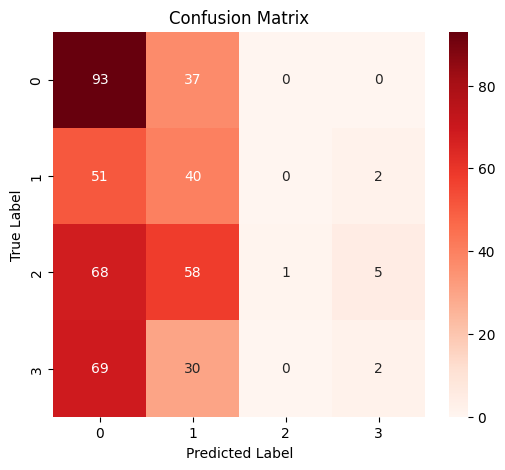

In [20]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds", xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")